In [1]:
import glob
import pickle

import numpy as np

from experiments.end_to_end.proof_node import ErrorNode, ProofFinishedNode

mini_f2f_traces = glob.glob('../runs/minif2f/minif2f_bestfs/2024_07_31/16_28_47/traces/0/*')



In [2]:
from experiments.end_to_end.proof_node import InternalNode


def get_valid_children(node):
    return len([d.dst[0] for d in node.out_edges if
                node.out_edges and not isinstance(d.dst[0], ErrorNode) and not isinstance(d.dst[0], ProofFinishedNode)])
def get_valid_children_2(node):
    # get valid tactics:
    valid_tactics = set()
    seen = set()
    for response in node.out_edges:
        result = response.dst

        for result_node in result:
            # Don't search proved/explored/queued nodes
            if isinstance(result_node,
                          InternalNode) and result_node not in seen:
                seen.add(result_node)
                tac = (response.tactic, response.tac_logprob)
                if tac not in valid_tactics:
                    valid_tactics.add(tac)
                    
    return len(valid_tactics)
    

In [3]:
import tqdm

valid_children = []

for trace in tqdm.tqdm(mini_f2f_traces):
    try:
        with open(trace, 'rb') as f:
            bestfs = pickle.load(f)
    except:
        print('error loading')
        continue
    if not bestfs:
        print('empty')
        continue
    for node in bestfs.nodes.values():
        if node.out_edges:
            valid_children.append(get_valid_children(node))


100%|██████████| 244/244 [00:14<00:00, 17.35it/s]


In [4]:
valid_children_2 = []

for trace in tqdm.tqdm(mini_f2f_traces):
    try:
        with open(trace, 'rb') as f:
            bestfs = pickle.load(f)
    except:
        print('error loading')
        continue
    if not bestfs:
        print('empty')
        continue
    for node in bestfs.nodes.values():
        if node.out_edges:
            valid_children_2.append(get_valid_children_2(node))


100%|██████████| 244/244 [00:11<00:00, 20.41it/s]


<Axes: ylabel='Count'>

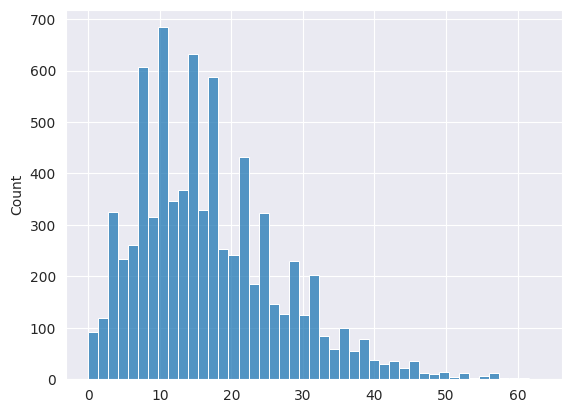

In [5]:
# plot the distribution of valid tactics (no direct error)

import seaborn as sns

sns.histplot(valid_children)


<Axes: ylabel='Count'>

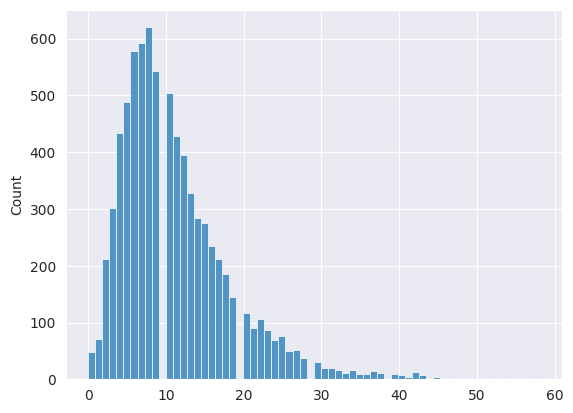

In [6]:
# plot the distribution of valid children (# tactics with a unique node)

sns.histplot(valid_children_2)


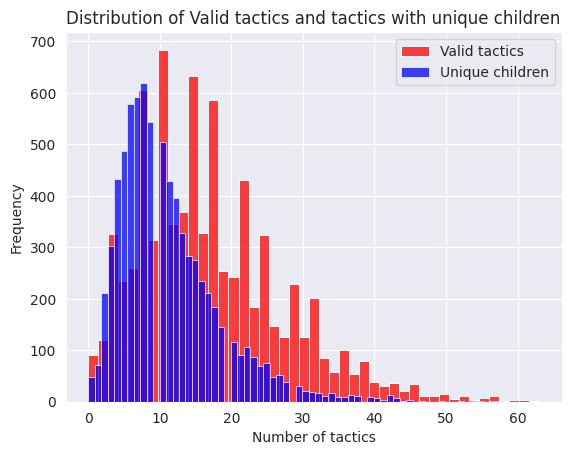

In [7]:
# overlay the two plots

import matplotlib.pyplot as plt
# add title, labels, legend
sns.histplot(valid_children, color='red', label='Valid tactics')
sns.histplot(valid_children_2, color='blue', label='Unique children')
plt.legend()
plt.title('Distribution of Valid tactics and tactics with unique children')
plt.xlabel('Number of tactics')
plt.ylabel('Frequency')
plt.show()


# takeaway: large number of valid tactics, but many of them are redundant (i.e. they lead to the same node)


In [8]:
sum([1 if v > 16 else 0 for v in valid_children_2]) / len(valid_children_2)

0.1857418111753372

In [9]:
with open(mini_f2f_traces[0], 'rb') as f:
    test = pickle.load(f)

In [10]:
test

SearchResult(theorem=Theorem(repo=LeanGitRepo(url='https://github.com/facebookresearch/miniF2F', commit='5271ddec788677c815cf818a06f368ef6498a106'), file_path=PosixPath('lean/src/valid.lean'), full_name='numbertheory_2dvd4expn'), status=<Status.PROVED: 'Proved'>, proof=['apply <a>dvd_pow</a>', 'norm_num', 'exact h₀'], tree=InternalNode(goal='n : ℕ,\nh₀ : n ≠ 0\n⊢ 2 ∣ 4 ^ n', _status=<Status.PROVED: 'Proved'>), total_time=97.80170493805781, tac_time=16.802001734031364, search_time=0.004383205319754779, env_time=80.99311549647246, num_expansions=448, num_nodes=107)

In [11]:
tac_times = []
env_times = []
expansions = []
num_nodes = []
fully_expanded = []

for trace in tqdm.tqdm(mini_f2f_traces):
    try:
        with open(trace, 'rb') as f:
            trace = pickle.load(f)
    except:
        print('error loading')
        continue
        
    tac_times.append(trace.tac_time)
    env_times.append(trace.env_time)
    expansions.append(trace.num_expansions)
    num_nodes.append(trace.num_nodes)
    fully_expanded.append(len([n for n in trace.nodes.values() if n.is_explored]))
    
    
    


100%|██████████| 244/244 [00:11<00:00, 20.39it/s]


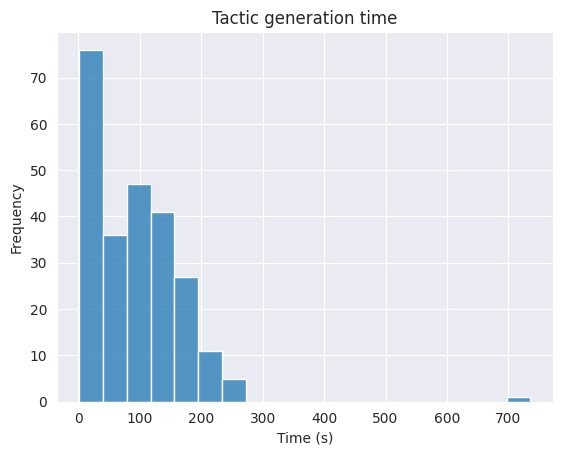

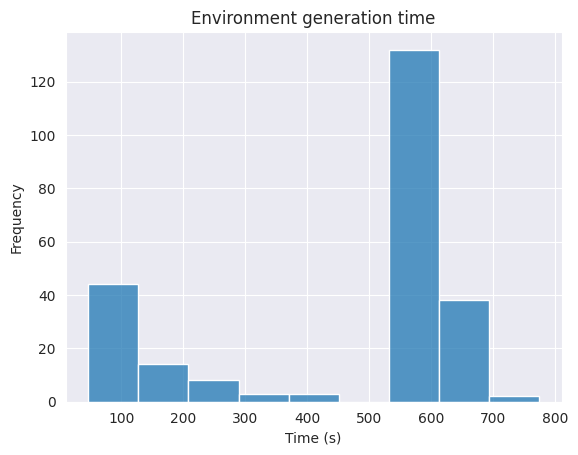

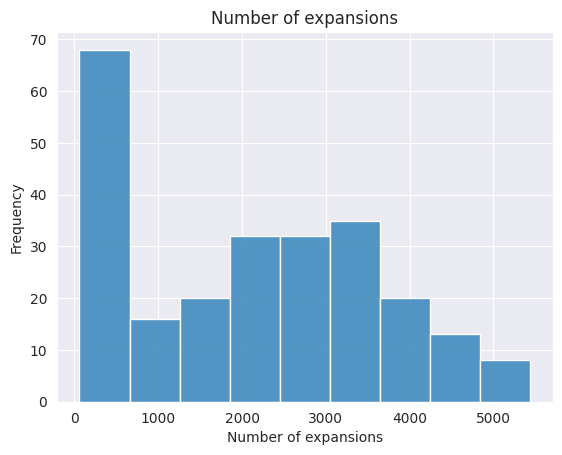

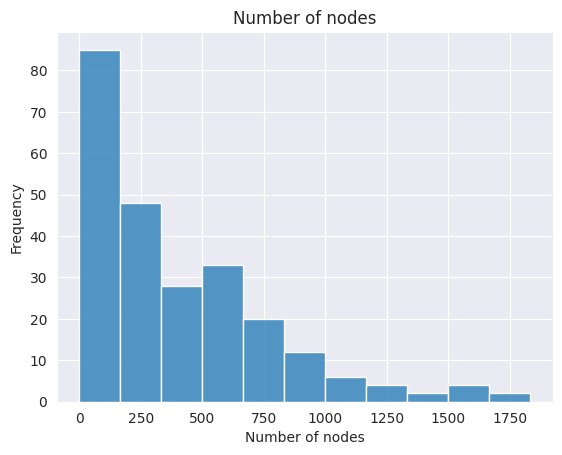

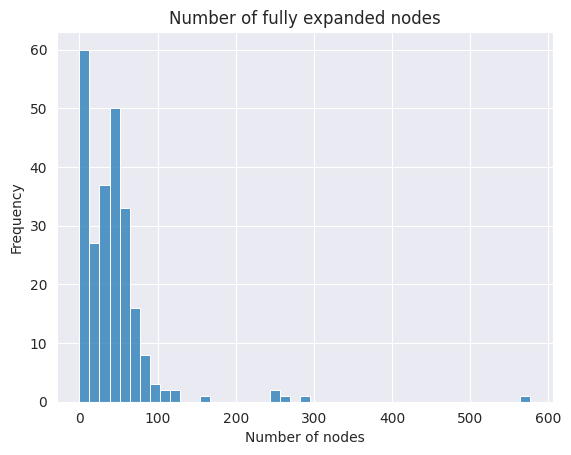

In [13]:
# histogram of all statistics above:

sns.histplot(tac_times)
plt.title('Tactic generation time')
plt.xlabel('Time (s)')
plt.ylabel('Frequency')
plt.show()

sns.histplot(env_times)
plt.title('Environment generation time')
plt.xlabel('Time (s)')
plt.ylabel('Frequency')
plt.show()

sns.histplot(expansions)
plt.title('Number of expansions')
plt.xlabel('Number of expansions')
plt.ylabel('Frequency') 
plt.show()

sns.histplot(num_nodes)
plt.title('Number of nodes')
plt.xlabel('Number of nodes')
plt.ylabel('Frequency')
plt.show()

sns.histplot(fully_expanded)
plt.title('Number of fully expanded nodes')
plt.xlabel('Number of nodes')
plt.ylabel('Frequency')
plt.show()
